In [18]:
import torch

## RAW OPL from the paper

In [19]:
import torch
import torch.nn.functional as F

def orthogonal_projection_loss(features, labels):
    """
    Computes OPL: (1 - s) + |d|
    features: Tensor of shape (Batch, Feature_Dim)
    labels: Tensor of shape (Batch,)
    """
    # 1. Normalize features to a unit hyper-sphere
    features = F.normalize(features, p=2, dim=1)

    # 2. Create masks for same-class (s) and different-class (d)
    batch_size = labels.size(0)
    labels_2d = labels.unsqueeze(1)

    # True if row i and col j are the same animal (e.g., Lion & Lion)
    mask_pos = torch.eq(labels_2d, labels_2d.t()).float()
    eye = torch.eye(batch_size, device=labels.device)
    mask_pos = mask_pos - eye # Remove self-comparisons

    # True if row i and col j are different animals (e.g., Lion & Tiger)
    mask_neg = 1.0 - mask_pos - eye

    # 3. Compute cosine similarity matrix (S = F * F^T)
    dot_prod = torch.matmul(features, features.t())

    # 4. Intra-class clustering (s): Packing the Lions tightly
    pos_sum = (mask_pos * dot_prod).sum()
    pos_mean = pos_sum / (mask_pos.sum() + 1e-6)

    # 5. Inter-class separation (d): Pushing enclosures 90 degrees apart
    neg_sum = (mask_neg * torch.abs(dot_prod)).sum()
    neg_mean = neg_sum / (mask_neg.sum() + 1e-6)

    # 6. Total Loss
    loss = (1.0 - pos_mean) + neg_mean
    return loss

## Training Scenario

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Scenario Setup: 10 Classes (Digits 0-9 / 10 Animal Zones)
num_classes = 10
feature_dim = 2 # Keeping the 2D bottleneck so we can plot the map later
batch_size = 64
learning_rate = 0.01

# 2. Real-World Data Pipeline (MNIST)
# Transform: Convert images to PyTorch tensors and normalize pixel values (-1 to 1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3. Upgraded Architecture: Convolutional ZooNet
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature Extractor: CNN to process 28x28 images
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Intermediate dense layer
        self.fc1 = nn.Linear(32 * 7 * 7, 128)

        # The 2D Bottleneck: This outputs the 'features' OPL will act upon
        self.feature_extractor = nn.Linear(128, feature_dim)

        # The Classifier: No bias, as typical for angular/margin-based losses
        self.classifier = nn.Linear(feature_dim, num_classes, bias=False)

    def forward(self, x):
        # Extract visual patterns
        x = self.pool(F.relu(self.conv1(x))) # Size: 14x14
        x = self.pool(F.relu(self.conv2(x))) # Size: 7x7

        # Flatten for dense layers
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))

        # Extract the 2D coordinates
        features = self.feature_extractor(x)

        # Classify based on the coordinates
        logits = self.classifier(features)

        return features, logits

# 4. Initialize models and optimizers for comparison
model_ce = MnistCNN()
model_opl = MnistCNN()

# Using Adam optimizer for faster convergence on CNNs compared to standard SGD
optimizer_ce = optim.Adam(model_ce.parameters(), lr=0.001)
optimizer_opl = optim.Adam(model_opl.parameters(), lr=0.001)
ce_loss_fn = nn.CrossEntropyLoss()

# 5. Example of fetching a real batch during a training loop
for images, labels in train_loader:
    # 'images' shape: (64, 1, 28, 28)
    # 'labels' shape: (64,)

    # --- CE ONLY Forward Pass ---
    features_ce, logits_ce = model_ce(images)
    loss_ce = ce_loss_fn(logits_ce, labels)

    # --- CE + OPL Forward Pass ---
    features_opl, logits_opl = model_opl(images)
    # (Assuming orthogonal_projection_loss function is defined as before)
    # loss_ortho = orthogonal_projection_loss(features_opl, labels)
    # total_loss = ce_loss_fn(logits_opl, labels) + (0.5 * loss_ortho)

    break # Breaking after one batch just to demonstrate the pipeline

### Visualize 
1) Feature space visualization for CE vs OPL 
2) (a) Feature orthogonality (↓) (b) Similarity of same class features (↑) (c) Similarity of different class features (↓)
Figure 3: Feature Analysis: We compare feature orthogonality as measured by OPL and feature similarity as measured by cosine sim-
ilarity and plot their convergence during training. Feature similarity is initially high because all features are random immediately after
initialization. OPL simultaneously enforces higher inter-class similarity and intra-class dissimilarity in comparison with the CE baseline.


Training on: cuda
Starting training...
Epoch [1/5]: 0.8534926176071167.
Epoch [2/5]: 0.6380570530891418.
Epoch [3/5]: 0.546924352645874.
Epoch [4/5]: 0.4128131866455078.
Epoch [5/5]: 0.5147871971130371.
Extracting features for visualization...


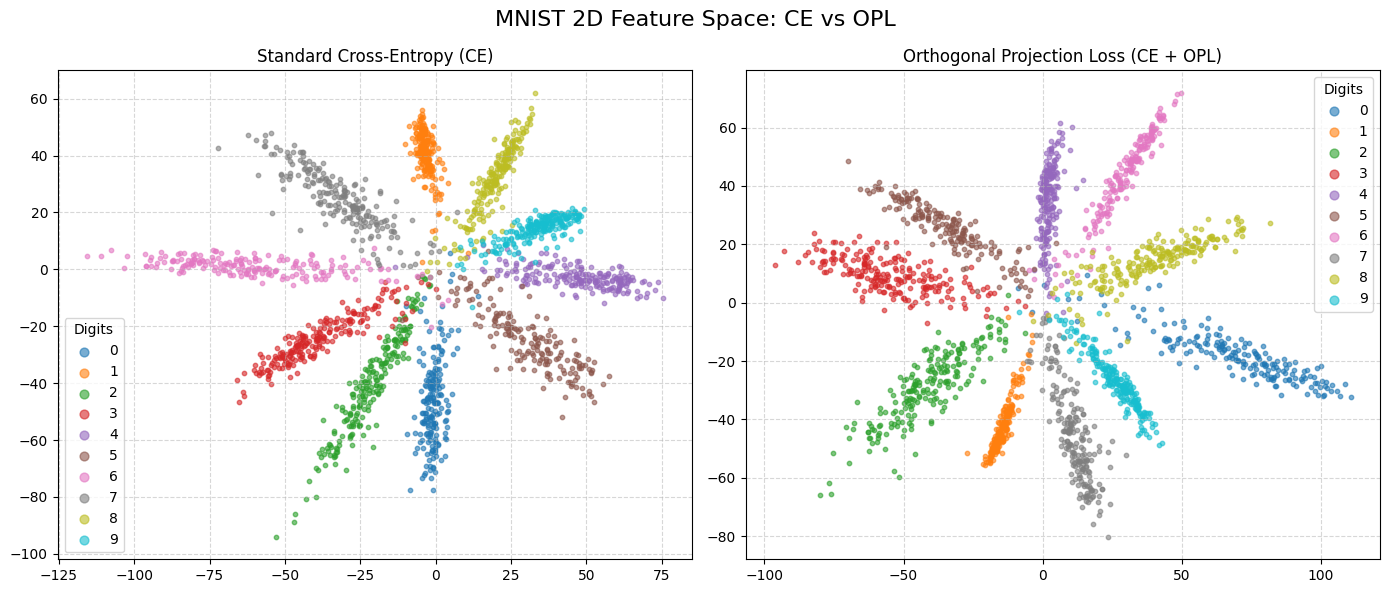

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- 1. OPL FUNCTION ---
def orthogonal_projection_loss(features, labels):
    features = F.normalize(features, p=2, dim=1)
    batch_size = labels.size(0)
    labels_2d = labels.unsqueeze(1)

    mask_pos = torch.eq(labels_2d, labels_2d.t()).float()
    eye = torch.eye(batch_size, device=labels.device)
    mask_pos = mask_pos - eye
    mask_neg = 1.0 - mask_pos - eye

    dot_prod = torch.matmul(features, features.t())

    pos_mean = (mask_pos * dot_prod).sum() / (mask_pos.sum() + 1e-6)
    neg_mean = (mask_neg * torch.abs(dot_prod)).sum() / (mask_neg.sum() + 1e-6)

    return (1.0 - pos_mean) + neg_mean

# --- 2. SETUP & DATA PIPELINE ---
num_classes = 10
feature_dim = 2
batch_size = 128
epochs = 5
lambda_weight = 0.5

# Device configuration (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Large batch for visualization
test_loader = DataLoader(test_dataset, batch_size=2000, shuffle=True)

# --- 3. ARCHITECTURE ---
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.feature_extractor = nn.Linear(128, feature_dim)
        self.classifier = nn.Linear(feature_dim, num_classes, bias=False)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return features, logits

# Initialize models
model_ce = CNN().to(device)
model_opl = CNN().to(device)

optimizer_ce = optim.Adam(model_ce.parameters(), lr=0.001)
optimizer_opl = optim.Adam(model_opl.parameters(), lr=0.001)
ce_loss_fn = nn.CrossEntropyLoss()

# --- 4. TRAINING LOOP ---
print("Starting training...")
for epoch in range(epochs):
    model_ce.train()
    model_opl.train()
    losses = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Train CE Baseline
        optimizer_ce.zero_grad()
        _, logits_ce = model_ce(images)
        loss_ce = ce_loss_fn(logits_ce, labels)
        loss_ce.backward()
        optimizer_ce.step()

        # Train CE + OPL
        optimizer_opl.zero_grad()
        features_opl, logits_opl = model_opl(images)
        loss_cls = ce_loss_fn(logits_opl, labels)
        loss_ortho = orthogonal_projection_loss(features_opl, labels)
        total_loss = loss_cls + (lambda_weight * loss_ortho)
        total_loss.backward()
        optimizer_opl.step()
        losses.append(total_loss)

    print(f"Epoch [{epoch+1}/{epochs}]: {losses[-1]}.")

# --- 5. FEATURE EXTRACTION & VISUALIZATION ---
print("Extracting features for visualization...")
model_ce.eval()
model_opl.eval()

with torch.no_grad():
    # Grab one large batch from the test set
    test_images, test_labels = next(iter(test_loader))
    test_images, test_labels = test_images.to(device), test_labels.to(device)

    features_ce, _ = model_ce(test_images)
    features_opl, _ = model_opl(test_images)

    # # Normalize OPL features for plotting (as they are normalized during loss calc)
    # features_opl = F.normalize(features_opl, p=2, dim=1)

# Move data to CPU for Matplotlib
feat_ce = features_ce.cpu().numpy()
feat_opl = features_opl.cpu().numpy()
lbls = test_labels.cpu().numpy()

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.get_cmap('tab10')

for i in range(num_classes):
    idx = lbls == i
    axs[0].scatter(feat_ce[idx, 0], feat_ce[idx, 1], c=[cmap(i)], label=str(i), alpha=0.6, s=10)
    axs[1].scatter(feat_opl[idx, 0], feat_opl[idx, 1], c=[cmap(i)], label=str(i), alpha=0.6, s=10)

axs[0].set_title("Standard Cross-Entropy (CE)")
axs[0].legend(title="Digits", loc="best", markerscale=2)
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].set_title("Orthogonal Projection Loss (CE + OPL)")
axs[1].legend(title="Digits", loc="best", markerscale=2)
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("MNIST 2D Feature Space: CE vs OPL", fontsize=16)
plt.tight_layout()
plt.show()

Training on: cuda
Starting training...
Epoch [1/5]: 0.7155663371086121.
Epoch [2/5]: 0.494472861289978.
Epoch [3/5]: 0.24726025760173798.
Epoch [4/5]: 0.16580036282539368.
Epoch [5/5]: 0.09931833297014236.
Extracting features for visualization...


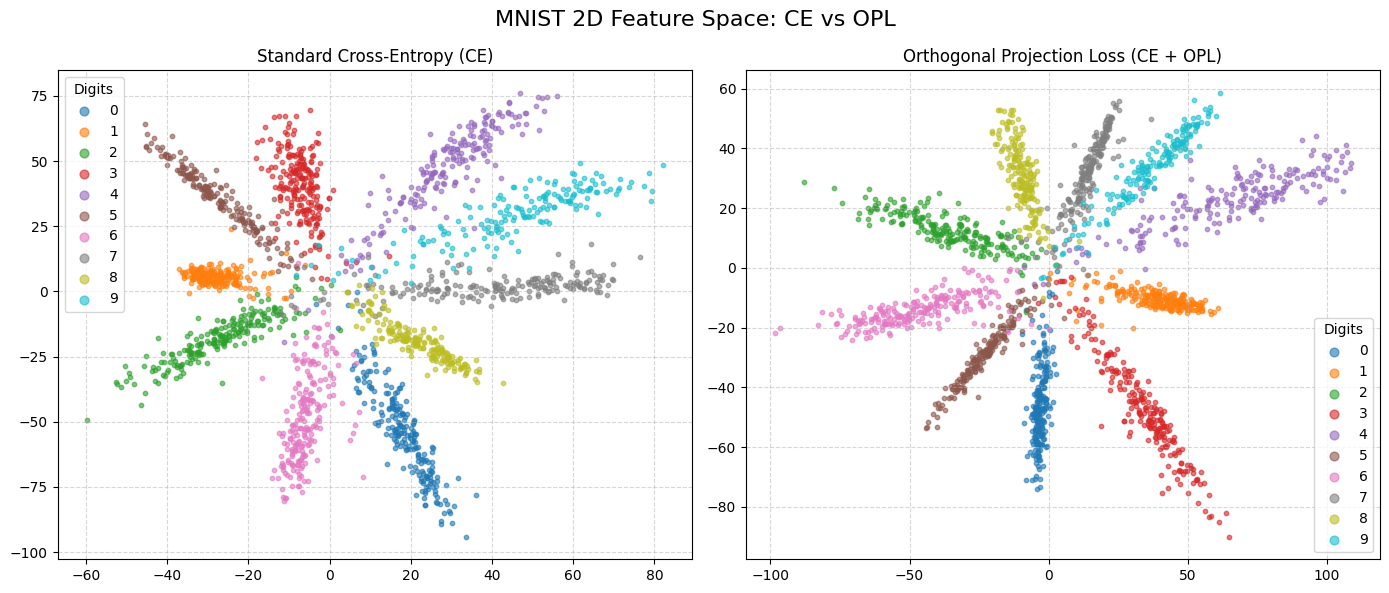

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- 1. OPL FUNCTION ---
def orthogonal_projection_loss(features, labels):
    features = F.normalize(features, p=2, dim=1)
    batch_size = labels.size(0)
    labels_2d = labels.unsqueeze(1)

    mask_pos = torch.eq(labels_2d, labels_2d.t()).float()
    eye = torch.eye(batch_size, device=labels.device)
    mask_pos = mask_pos - eye
    mask_neg = 1.0 - mask_pos - eye

    dot_prod = torch.matmul(features, features.t())

    pos_mean = (mask_pos * dot_prod).sum() / (mask_pos.sum() + 1e-6)
    neg_mean = (mask_neg * torch.abs(dot_prod)).sum() / (mask_neg.sum() + 1e-6)

    return (1.0 - pos_mean) + neg_mean

# --- 2. SETUP & DATA PIPELINE ---
num_classes = 10
feature_dim = 2
batch_size = 128
epochs = 5
lambda_weight = 0.5

# Device configuration (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Large batch for visualization
test_loader = DataLoader(test_dataset, batch_size=2000, shuffle=True)

# --- 3. ARCHITECTURE ---
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.feature_extractor = nn.Linear(128, feature_dim)
        self.classifier = nn.Linear(feature_dim, num_classes, bias=False)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return features, logits

# Initialize models
model_ce = CNN().to(device)
model_opl = CNN().to(device)

optimizer_ce = optim.Adam(model_ce.parameters(), lr=0.001)
optimizer_opl = optim.Adam(model_opl.parameters(), lr=0.001)
ce_loss_fn = nn.CrossEntropyLoss()

# --- 4. TRAINING LOOP ---
print("Starting training...")
for epoch in range(epochs):
    model_ce.train()
    model_opl.train()
    losses = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Train CE Baseline
        optimizer_ce.zero_grad()
        _, logits_ce = model_ce(images)
        loss_ce = ce_loss_fn(logits_ce, labels)
        loss_ce.backward()
        optimizer_ce.step()

        # Train CE + OPL
        optimizer_opl.zero_grad()
        features_opl, logits_opl = model_opl(images)
        loss_cls = ce_loss_fn(logits_opl, labels)
        total_loss = loss_cls
        total_loss.backward()
        optimizer_opl.step()
        losses.append(total_loss)

    print(f"Epoch [{epoch+1}/{epochs}]: {losses[-1]}.")

# --- 5. FEATURE EXTRACTION & VISUALIZATION ---
print("Extracting features for visualization...")
model_ce.eval()
model_opl.eval()

with torch.no_grad():
    # Grab one large batch from the test set
    test_images, test_labels = next(iter(test_loader))
    test_images, test_labels = test_images.to(device), test_labels.to(device)

    features_ce, _ = model_ce(test_images)
    features_opl, _ = model_opl(test_images)

    # # Normalize OPL features for plotting (as they are normalized during loss calc)
    # features_opl = F.normalize(features_opl, p=2, dim=1)

# Move data to CPU for Matplotlib
feat_ce = features_ce.cpu().numpy()
feat_opl = features_opl.cpu().numpy()
lbls = test_labels.cpu().numpy()

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.get_cmap('tab10')

for i in range(num_classes):
    idx = lbls == i
    axs[0].scatter(feat_ce[idx, 0], feat_ce[idx, 1], c=[cmap(i)], label=str(i), alpha=0.6, s=10)
    axs[1].scatter(feat_opl[idx, 0], feat_opl[idx, 1], c=[cmap(i)], label=str(i), alpha=0.6, s=10)

axs[0].set_title("Standard Cross-Entropy (CE)")
axs[0].legend(title="Digits", loc="best", markerscale=2)
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].set_title("Orthogonal Projection Loss (CE + OPL)")
axs[1].legend(title="Digits", loc="best", markerscale=2)
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("MNIST 2D Feature Space: CE vs OPL", fontsize=16)
plt.tight_layout()
plt.show()